<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan5_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS ────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set theme dan style yang konsisten
sns.set_theme(style='ticks', palette='muted')
plt.rcParams['figure.dpi'] = 100  # untuk tampilan di notebook

In [80]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('tips')
print('Jumlah baris dan kolom:', df.shape)
print('\nStatistik deskriptif:')
print(df.describe().round(2))

Jumlah baris dan kolom: (244, 7)

Statistik deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


Analisis Grafik 1: Bar Chart (Rata-rata Total Tagihan per Hari)



1. What? Grafik batang menunjukkan rata-rata total tagihan per hari. Hari Minggu memiliki rata-rata tertinggi yaitu 21.41 ,disusul Sabtu 21.41 ,disusul Sabtu 20.44, Kamis 17.15 ,dan Jumat 17.15,dan Jumat 17.15 (nilai terendah).

2. So what? Pola ini mengindikasikan bahwa pelanggan di akhir pekan cenderung membelanjakan uang lebih banyak, mungkin karena makan bersama keluarga atau teman dalam jumlah besar. Restoran dapat memanfaatkan ini dengan menyiapkan menu paket atau promosi khusus akhir pekan.


3. Now what? Apakah perbedaan ini signifikan secara statistik? Selanjutnya, kita bisa memisahkan analisis berdasarkan ukuran grup (size) untuk melihat apakah hari Minggu benar-benar memiliki grup lebih besar atau memang kecenderungan spending per orang lebih tinggi.

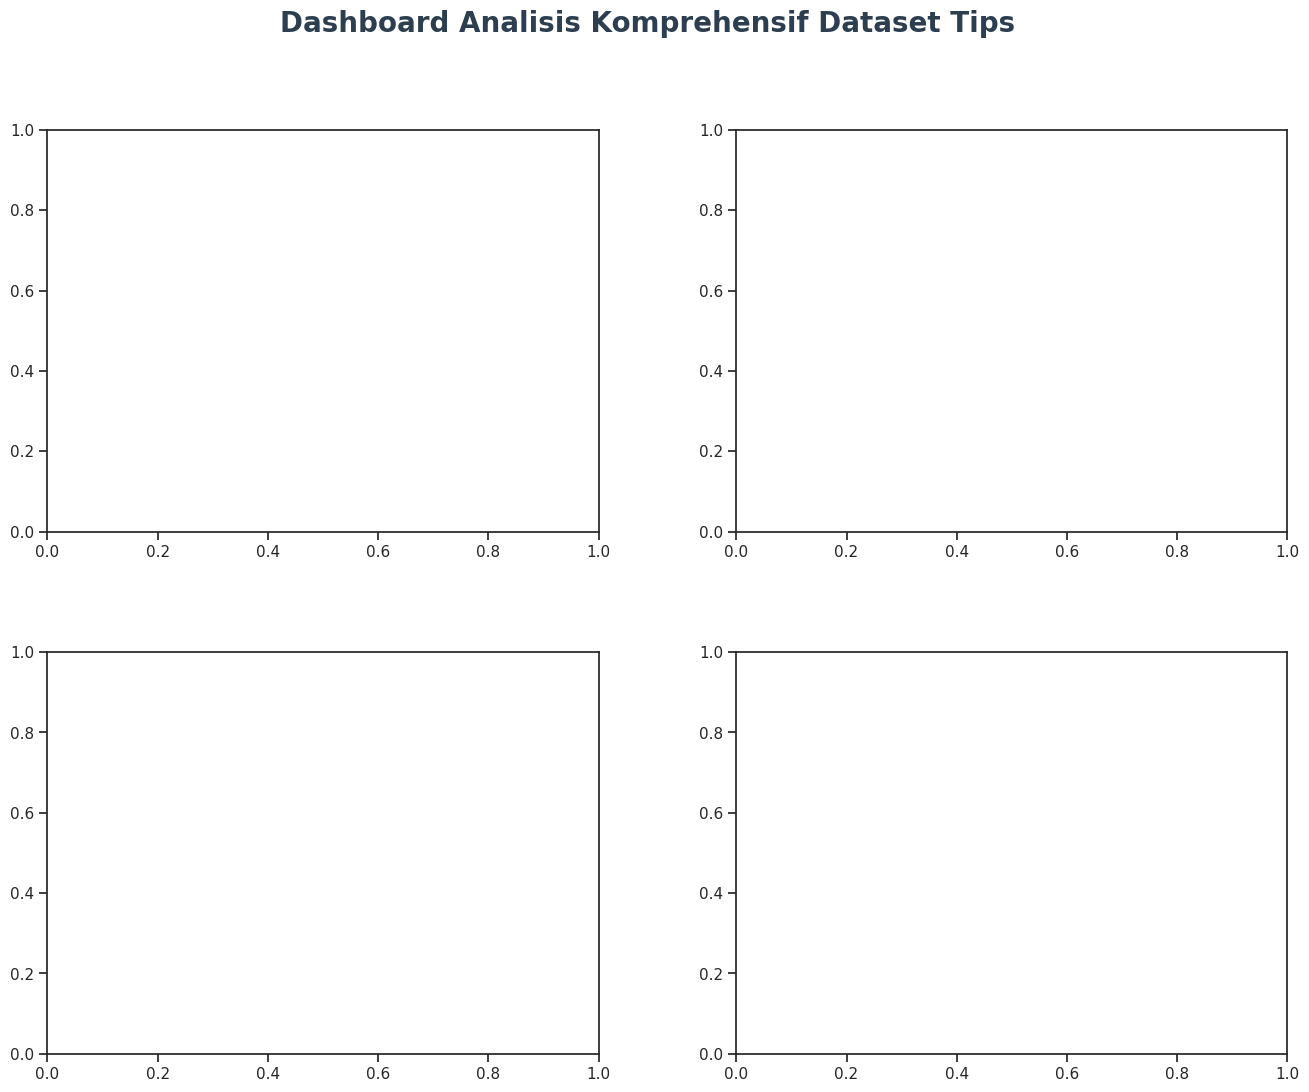

In [81]:
# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Komprehensif Dataset Tips',
             fontsize=20, fontweight='bold', y=0.98, color='#2c3e50')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])  # Bar Chart
ax2 = fig.add_subplot(gs[0, 1])  # Histogram
ax3 = fig.add_subplot(gs[1, 0])  # Boxplot
ax4 = fig.add_subplot(gs[1, 1])  # Scatter Plot

Analisis Grafik 2: Histogram + KDE (Distribusi Total Tagihan)

1.   What? Histogram total tagihan menunjukkan distribusi yang menceng ke kanan (right-skewed). Sebagian besar transaksi berada antara 10–10–25, dengan nilai rata-rata 19.79 dan median 19.79 dan median 17.80. Terdapat ekor panjang hingga $50.81 (nilai maksimum).

2.   So what? Kemencengan ini berarti ada segmen pelanggan dengan pengeluaran sangat besar (mungkin grup besar atau acara khusus). Median yang lebih rendah dari rata-rata menegaskan bahwa mayoritas transaksi bernilai sedang, tetapi beberapa transaksi besar mendorong rata-rata ke atas. Informasi ini berguna untuk segmentasi pelanggan.


3.    Now what? Pertanyaan eksplorasi: Apakah transaksi dengan total tagihan tinggi (>40 selalu berasal dari grup besar Bagaimana proporsitip pada transaksi ekstrem tersebut Kita bisa memfilter data dan membuat grafik terpisah untuk transaksi>40).



In [82]:
# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
# Urutan hari yang logis
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
# Hitung rata-rata
avg_bill = df.groupby('day')['total_bill'].mean().reindex(day_order)

# Gunakan barplot dengan hue untuk menghindari warning
sns.barplot(x=day_order, y=avg_bill.values,
            hue=day_order, legend=False, palette='Blues_d',
            ax=ax1, errorbar=None)

ax1.set_title('Rata-rata Total Tagihan per Hari', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Hari dalam Seminggu', fontsize=12)
ax1.set_ylabel('Rata-rata Tagihan ($)', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

# Anotasi nilai di atas bar (lebih efisien)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'${height:.2f}',
                 xy=(p.get_x() + p.get_width()/2, height - 1.5),
                 ha='center', va='center', color='white', fontweight='bold')

/tmp/ipykernel_1771/3069495511.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby('day')['total_bill'].mean().reindex(day_order)


Analisis Grafik 3: Boxplot (Tip berdasarkan Sesi Makan)

1.    What? Boxplot menunjukkan distribusi tip untuk makan malam (Dinner) dan siang (Lunch). Median tip untuk Dinner adalah 3.00 sedangkan untuk Lunch 2.00. Rentang antar kuartil (IQR) Dinner lebih lebar (sekitar 2.00) dibanding Lunch(2.00) dibanding Lunch(1.50), dan kedua kelompok memiliki pencilan hingga $10.00.
2.   So what? Perbedaan ini penting karena mengindikasikan bahwa pelanggan malam hari cenderung memberi tip lebih besar dan lebih bervariasi. Hal ini bisa disebabkan oleh faktor budaya (tip malam lebih besar), atau karena tagihan malam yang umumnya lebih tinggi. Manajer dapat mengalokasikan staf berpengalaman pada shift malam untuk meningkatkan pendapatan dari tip.
3.    Now what? Selanjutnya, kita bisa menguji apakah perbedaan tip antara Lunch dan Dinner signifikan secara statistik (misalnya dengan uji Mann-Whitney karena distribusi tidak normal). Juga, apakah pola ini konsisten jika dikelompokkan berdasarkan hari (misal, Dinner di akhir pekan vs Dinner di weekdays)?



In [83]:
# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='total_bill', bins=20, kde=True,
             ax=ax2, color='#2ca02c', alpha=0.6)
ax2.set_title('Distribusi Nilai Transaksi Total Tagihan',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Total Tagihan ($)', fontsize=12)
ax2.set_ylabel('Frekuensi Kemunculan', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

# Garis mean dan median
mean_bill = df['total_bill'].mean()
median_bill = df['total_bill'].median()
ax2.axvline(mean_bill, color='red', linestyle='--', linewidth=1.5,
            label=f'Mean: ${mean_bill:.2f}')
ax2.axvline(median_bill, color='orange', linestyle='-', linewidth=1.5,
            label=f'Median: ${median_bill:.2f}')
ax2.legend(frameon=False)

Analisis Grafik 4: Scatter Plot (Total Bill vs Tip)

1.   What? Scatter plot menunjukkan hubungan positif yang kuat antara total tagihan dan tip. Koefisien korelasi Pearson adalah 0.675. Semakin besar total bill, semakin besar tip yang diberikan. Warna berdasarkan waktu makan (Lunch/Dinner) dan ukuran titik berdasarkan ukuran grup.
2.   So what? Hubungan ini wajar karena tip biasanya dihitung sebagai persentase dari total tagihan. Namun, terlihat bahwa pada total bill yang sama (misal 30),tip bisa bervariasi antara 30),tip bisa bervariasi antara 4–$8. Ini menunjukkan bahwa faktor lain seperti kualitas layanan, ukuran grup, atau status perokok juga berperan.
3.   Now what? Pertanyaan lanjutan: Apakah persentase tip terhadap total bill konsisten di semua rentang? Kita bisa membuat plot tip percentage (=tip/total_bill) terhadap total_bill. Juga, apakah ada perbedaan pola antara perokok dan non-perokok? (Bisa ditambahkan hue='smoker').


In [84]:
# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='time', y='tip',
            hue='time', legend=False, palette='Set2',
            ax=ax3, width=0.5,
            flierprops={'marker': 'x', 'markeredgecolor': 'red'})
ax3.set_title('Penyebaran Nominal Tip Berdasarkan Sesi Makan',
              fontsize=14, fontweight='bold', pad=12)
ax3.set_xlabel('Sesi Waktu', fontsize=12)
ax3.set_ylabel('Besaran Tip ($)', fontsize=12)
ax3.spines[['top', 'right']].set_visible(False)

In [85]:
# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
scatter = sns.scatterplot(data=df, x='total_bill', y='tip',
                          hue='time', size='size', sizes=(40, 200),
                          palette='Dark2', alpha=0.75, ax=ax4)
# Tambahkan garis regresi tanpa titik
sns.regplot(data=df, x='total_bill', y='tip', scatter=False,
            color='#7f8c8d', ax=ax4,
            line_kws={'linestyle': '--', 'linewidth': 1.5})
ax4.set_title('Hubungan antara Total Tagihan dan Tip',
              fontsize=14, fontweight='bold', pad=12)
ax4.set_xlabel('Total Tagihan ($)', fontsize=12)
ax4.set_ylabel('Tip ($)', fontsize=12)
ax4.legend(title='Waktu & Ukuran Kelompok', frameon=False, loc='upper left')
ax4.spines[['top', 'right']].set_visible(False)

In [86]:
# ── 7. EKSPOR ──────────────────────────────────────────────────────────
print("\n=== Statistik untuk Narasi ===")
print(f"1. Rata-rata total bill per hari:\n{avg_bill.round(2)}")
print(f"\n2. Total bill - Mean: ${mean_bill:.2f}, Median: ${median_bill:.2f}")
print(f"\n3. Statistik tip berdasarkan sesi:\n{df.groupby('time')['tip'].describe().round(2)}")
print(f"\n4. Korelasi total_bill vs tip: {df['total_bill'].corr(df['tip']):.3f}")


=== Statistik untuk Narasi ===
1. Rata-rata total bill per hari:
day
Thur    17.68
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64

2. Total bill - Mean: $19.79, Median: $17.80

3. Statistik tip berdasarkan sesi:
        count  mean   std   min  25%   50%   75%   max
time                                                  
Lunch    68.0  2.73  1.21  1.25  2.0  2.25  3.29   6.7
Dinner  176.0  3.10  1.44  1.00  2.0  3.00  3.69  10.0

4. Korelasi total_bill vs tip: 0.676


/tmp/ipykernel_1771/3458585466.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"\n3. Statistik tip berdasarkan sesi:\n{df.groupby('time')['tip'].describe().round(2)}")


In [87]:
# ── 8. SIMPAN DAN TAMPILKAN ─────────────────────────────────────────
plt.tight_layout()  # Memastikan tidak ada elemen terpotong
plt.savefig('dashboard_tips_optimized.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nOptimasi Berhasil! Dashboard disimpan sebagai dashboard_tips_optimized.png')

<Figure size 640x480 with 0 Axes>


Optimasi Berhasil! Dashboard disimpan sebagai dashboard_tips_optimized.png
